Importing

In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load the dataset
data = pd.read_csv("C:/Users/lanke/OneDrive/Documents/DATA MINING/synthetic_hospital_data_modified.csv")

# Drop the 'Patient ID' as it is not relevant for clustering
data = data.drop('Patient ID', axis=1)
data.head()



,Age,Gender,Medical History,Number of Visits,Total Medical Expenses,Treatment Adherence Score,Disease Type,Severity Level,Age Group,Chronic Condition,Treatment Plan
0,23,Female,Chronic Kidney Disease,16,19185,1,Kidney Disease,Severe,19-35,1,Ongoing
1,26,Male,Hypertension,1,1444,8,Cardiovascular Disease,Mild,19-35,1,Short-term
2,74,Male,Arthritis,16,2552,33,Musculoskeletal Disease,Severe,66+,0,Ongoing
3,48,Male,Cancer,6,11042,68,Cancer,Moderate,36-50,0,Long-term
4,38,Male,Hypertension,14,8203,50,Cardiovascular Disease,Moderate,36-50,1,Long-term


In [2]:
data.shape

(10000, 11)

Preprocessing

In [3]:
# Define preprocessing for numeric and categorical features
numeric_features = ['Age', 'Number of Visits', 'Total Medical Expenses', 'Treatment Adherence Score']
categorical_features = ['Gender', 'Medical History']

# Create transformers
numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Apply preprocessing
X_preprocessed = preprocessor.fit_transform(data)

Here, two lists are defined: numeric_features contains the names of the numeric columns in the dataset, while categorical_features contains the names of the categorical columns.

StandardScaler(): This transformer standardizes the numeric features by removing the mean and scaling to unit variance. This is important for algorithms that are sensitive to the scale of data, such as K-means clustering.

OneHotEncoder(): This transformer converts categorical variables into a format that can be provided to ML algorithms to do a better job in prediction. It creates binary columns for each category in the categorical features.

ColumnTransformer: This combines the numeric and categorical transformers into a single preprocessing step. It applies StandardScaler to the numeric features and OneHotEncoder to the categorical features, allowing for simultaneous preprocessing of different types of data.

X_preprocessed = preprocessor.fit_transform(data) :This line applies the defined preprocessing steps to the dataset data. The fit_transform method first fits the transformers to the data (calculating necessary statistics like mean and variance for scaling) and then transforms the data accordingly.
The result, X_preprocessed, is a NumPy array containing the transformed features, ready for further analysis or modeling.



PCA

In [4]:
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensions
pca = PCA(n_components=5)  # Assuming we want to keep the first 5 components
X_pca = pca.fit_transform(X_preprocessed)

# Explained variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
print("Explained variance ratio:", explained_variance)
print("Cumulative explained variance:", cumulative_variance)


Explained variance ratio: [0.19094783 0.18605576 0.18318884 0.18221866 0.09277377]
Cumulative explained variance: [0.19094783 0.3770036  0.56019244 0.74241109 0.83518486]


Creating PCA Instance: pca = PCA(n_components=5) initializes a PCA object that will reduce the dataset to 5 principal components. This means that the original data will be transformed into a new space defined by these 5 components.

Fitting and Transforming: X_pca = pca.fit_transform(X_preprocessed) performs two operations:
Fit: It computes the principal components from the preprocessed data (X_preprocessed), determining the directions (components) in which the data varies the most.
Transform: It then projects the original data into the new PCA space, resulting in X_pca, which contains the transformed data with reduced dimensions.

Explained Variance Ratio: explained_variance = pca.explained_variance_ratio_ retrieves the proportion of the dataset's variance that is explained by each of the selected principal components. This helps in understanding how much information (variance) is retained after dimensionality reduction.

Cumulative Variance: cumulative_variance = np.cumsum(explained_variance) calculates the cumulative sum of the explained variance ratios. This shows how much total variance is explained as you include more components. For example, if the first two components explain 70% of the variance, the cumulative variance for those two components would be 0.70.

Choosing K and clustering

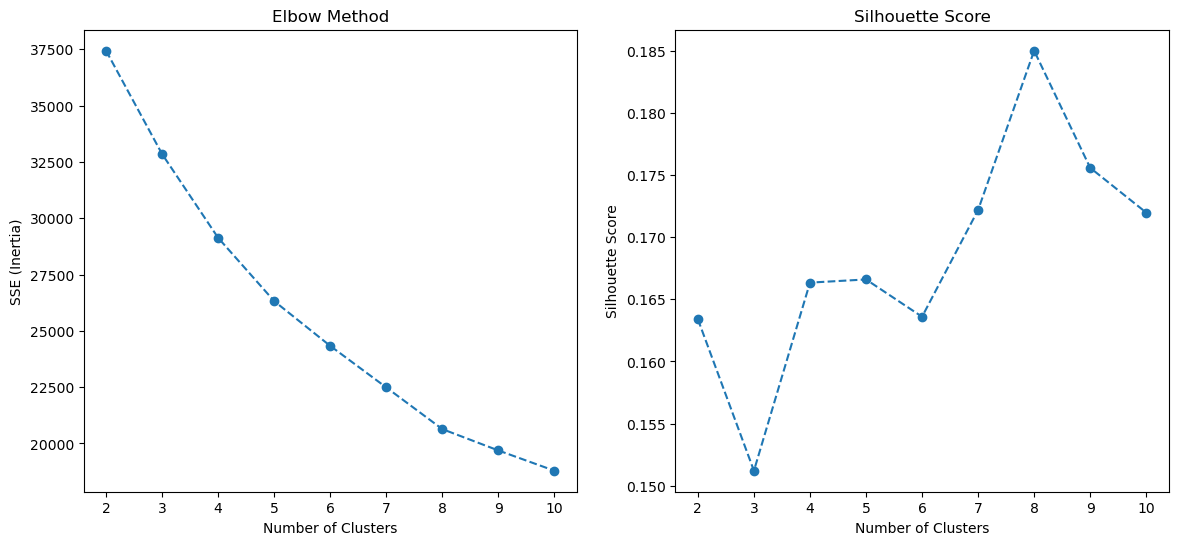

In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

cluster_range = range(2, 11)
sse = []
silhouette_scores = []

for k in cluster_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    cluster_labels = kmeans.fit_predict(X_pca)
    sse.append(kmeans.inertia_)
    
    if len(np.unique(cluster_labels)) > 1:  # Ensure more than one cluster
        score = silhouette_score(X_pca, cluster_labels)
    else:
        score = None  # Placeholder for invalid scores
    
    silhouette_scores.append(score)

# Plot Elbow Method
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(cluster_range, sse, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('SSE (Inertia)')
plt.title('Elbow Method')

# Plot Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(cluster_range, silhouette_scores, marker='o', linestyle='--')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score')

plt.show()



Looping through cluster counts: For each value of k
k in cluster_range, the code:
Initializes a KMeans object with n_clusters=k, setting n_init=10 to run the algorithm 10 times with different centroid seeds and random_state=42 for reproducibility.

Fits the KMeans model to the PCA-transformed data (X_pca) and predicts the cluster labels.
SSE Calculation: The inertia (SSE) is stored in the sse list, which measures how tightly the clusters are packed (lower values indicate tighter clusters).

Silhouette Score Calculation: The silhouette score is calculated only if there is more than one unique cluster label. This score measures how similar an object is to its own cluster compared to other clusters. A higher score indicates better-defined clusters. If only one cluster is formed, the score is set to None.

Creating Subplots: A figure is created with two subplots to visualize the results of the clustering evaluation.

Elbow Method Plot: The first subplot shows the SSE for each cluster count. The "elbow" point (where the SSE starts to decrease at a slower rate) indicates a suitable number of clusters.

Silhouette Score Plot: The second subplot displays the silhouette scores for each cluster count. A higher silhouette score suggests better-defined clusters.

In [6]:
# Choose optimal number of clusters based on Elbow Method and Silhouette Score
optimal_n_clusters = 8
kmeans = KMeans(n_clusters=optimal_n_clusters, n_init=10, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)

# Add cluster labels to the original DataFrame
data['Cluster'] = cluster_labels


KMeans Initialization: The KMeans object is created with the following parameters:
n_clusters=optimal_n_clusters: Specifies that the algorithm should create 8 clusters.

n_init=10: This parameter indicates that the algorithm should run 10 times with different centroid seeds to find the best clustering solution.

random_state=42: This ensures reproducibility of the results by setting a seed for the random number generator.
Fitting and Predicting: The fit_predict method is called on the PCA-transformed data (X_pca):
This method fits the K-Means model to the data and simultaneously assigns each data point to one of the 8 clusters.
The resulting cluster labels for each data point are stored in the cluster_labels variable.

Plotting Cluster

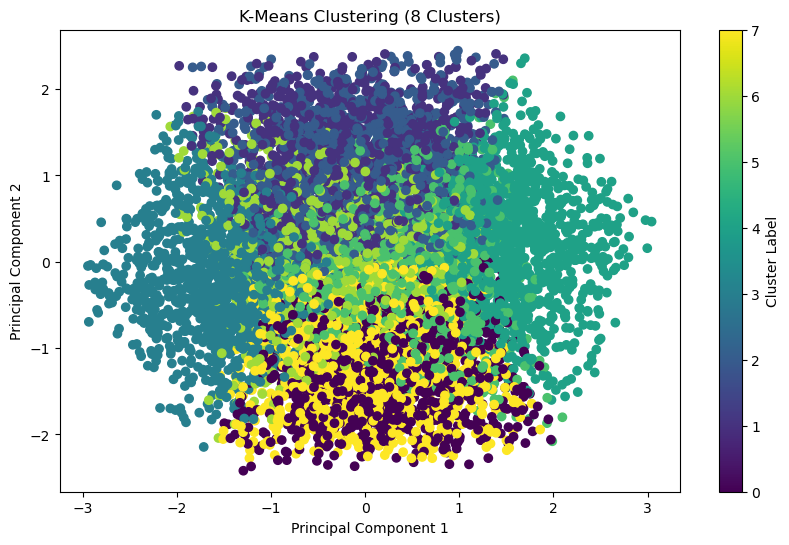

In [7]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', marker='o')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('K-Means Clustering (8 Clusters)')
plt.colorbar(scatter, label='Cluster Label')
plt.show()

3D PLot

In [8]:
import plotly.express as px
import webbrowser
import os

# Create a DataFrame with the first three principal components
df_pca = pd.DataFrame(X_pca[:, :3], columns=['PC1', 'PC2', 'PC3'])
df_pca['Cluster'] = cluster_labels

# Create the interactive 3D scatter plot
fig = px.scatter_3d(df_pca, x='PC1', y='PC2', z='PC3',
                    color='Cluster',
                    title='3D Scatter Plot of K-Means Clusters',
                    labels={'PC1': 'Principal Component 1',
                            'PC2': 'Principal Component 2',
                            'PC3': 'Principal Component 3'})

fig.write_html('3d_scatter_plot.html')
webbrowser.open(os.path.abspath('3d_scatter_plot.html'))


True

Accuracy

In [9]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

# Silhouette Score
silhouette_avg = silhouette_score(X_pca, cluster_labels)
print(f'Silhouette Score: {silhouette_avg}')

# Calinski-Harabasz Index
calinski_harabasz = calinski_harabasz_score(X_pca, cluster_labels)
print(f'Calinski-Harabasz Index: {calinski_harabasz}')

# Davies-Bouldin Index
davies_bouldin = davies_bouldin_score(X_pca, cluster_labels)
print(f'Davies-Bouldin Index: {davies_bouldin}')

from sklearn.metrics import pairwise_distances

def dunn_index(X, labels):
    # Get unique cluster labels
    unique_labels = np.unique(labels)
    
    # Calculate intra-cluster distances
    intra_distances = []
    for label in unique_labels:
        cluster_points = X[labels == label]
        if len(cluster_points) > 1:
            intra_distances.append(np.mean(pairwise_distances(cluster_points)))
    
    # Calculate inter-cluster distances
    inter_distances = []
    for i in range(len(unique_labels)):
        for j in range(i + 1, len(unique_labels)):
            cluster_i = X[labels == unique_labels[i]]
            cluster_j = X[labels == unique_labels[j]]
            inter_distances.append(np.mean(pairwise_distances(cluster_i, cluster_j)))
    
    # Calculate Dunn index
    if intra_distances and inter_distances:
        return min(inter_distances) / max(intra_distances)
    else:
        return None  # Return None if distances cannot be computed

# Assuming X_pca is your PCA-reduced data and cluster_labels are your cluster assignments
dunn_index_value = dunn_index(X_pca, cluster_labels)
print(f'Dunn Index: {dunn_index_value}')

Silhouette Score: 0.1849839533766386
Calinski-Harabasz Index: 1685.5527021152234
Davies-Bouldin Index: 1.2983040996877149
Dunn Index: 1.4630932559727445


Silhouette Score (0.185): The clusters are not well-separated, indicating potential overlap or suboptimal clustering.

Calinski-Harabasz Index (1685.58): There is some density and separation in the clusters, but further improvements may be needed.

Davies-Bouldin Index (1.297): The clusters are moderately separated, suggesting room for enhanced cluster definition.

Dunn Index Value (1.463): suggests a reasonable level of separation between the clusters and their compactness.

In [10]:
from sklearn.metrics import pairwise_distances_argmin_min


centroids = kmeans.cluster_centers_
# Calculate the Euclidean and Manhattan distances of each point to its cluster centroid
euclidean_distances = np.linalg.norm(X_pca - centroids[cluster_labels], axis=1)
manhattan_distances = np.abs(X_pca - centroids[cluster_labels]).sum(axis=1)

# Add these distances to the DataFrame
data['Euclidean Distance'] = euclidean_distances
data['Manhattan Distance'] = manhattan_distances

# Display the DataFrame with distances
print(data[['Cluster', 'Euclidean Distance', 'Manhattan Distance']].head())


   Cluster  Euclidean Distance  Manhattan Distance
0        3            1.580100            2.911068
1        2            1.635155            3.307105
2        1            1.020926            1.940107
3        0            1.093238            2.200337
4        6            1.194098            2.513544


Euclidean Distances:
np.linalg.norm(X_pca - centroids[cluster_labels], axis=1) calculates the Euclidean distance for each data point in X_pca to its corresponding cluster centroid. The expression centroids[cluster_labels] selects the centroid for each point based on its assigned cluster label.
Manhattan Distances:
np.abs(X_pca - centroids[cluster_labels]).sum(axis=1) computes the Manhattan distance (or L1 norm) for each data point to its centroid. This distance is the sum of the absolute differences between the coordinates of the data point and its centroid.

In [11]:
# Check unique cluster labels
unique_clusters = data['Cluster'].unique()
print("Unique clusters present:", unique_clusters)


Unique clusters present: [3 2 1 0 6 4 7 5]


In [12]:
# Display one example from each cluster
sample_from_each_cluster = data.groupby('Cluster').head(1)
print(sample_from_each_cluster[['Cluster', 'Euclidean Distance', 'Manhattan Distance']])


    Cluster  Euclidean Distance  Manhattan Distance
0         3            1.580100            2.911068
1         2            1.635155            3.307105
2         1            1.020926            1.940107
3         0            1.093238            2.200337
4         6            1.194098            2.513544
6         4            1.686326            3.058821
7         7            1.089936            2.189478
15        5            1.253092            2.626804


This code groups the DataFrame by the Cluster column and retrieves the first entry from each cluster using head(1). It then prints the Cluster, Euclidean Distance, and Manhattan Distance for these representative entries. This gives insight into the distances of one example from each identified cluster.

In [13]:
# Summary statistics for each cluster
cluster_summary = data.groupby('Cluster').agg({
    'Age': ['mean', 'std'],
    'Number of Visits': ['mean', 'std'],
    'Total Medical Expenses': ['mean', 'std'],
    'Treatment Adherence Score': ['mean', 'std']
})

print(cluster_summary)



               Age            Number of Visits            \
              mean        std             mean       std   
Cluster                                                    
0        38.898824  13.421027         5.860392  3.587125   
1        68.414750  13.384251        14.102300  3.600684   
2        36.619968  12.747047         5.719807  3.318263   
3        36.195122  12.397622        14.083841  3.521621   
4        71.798555  12.159464         5.916533  3.515122   
5        68.793538  13.245317         5.689519  3.367790   
6        36.892979  12.819143        13.873288  3.597253   
7        70.403423  12.735908        14.492258  3.336079   

        Total Medical Expenses              Treatment Adherence Score  \
                          mean          std                      mean   
Cluster                                                                 
0                 14802.598431  3485.880609                 75.139608   
1                  5758.971451  3464.780635    

This table provides a summary of the clusters obtained from the dataset, showing the mean and standard deviation of various attributes for each cluster. This kind of summary is useful for understanding the typical characteristics of each cluster and how they differ from one another. Let's break down the interpretation of each attribute for the clusters.

### Cluster Characteristics

Each cluster is defined by the following attributes:

- *Age*: The mean and standard deviation of the ages of individuals in each cluster.
- *Number of Visits*: The mean and standard deviation of the number of visits made by individuals in each cluster.
- *Total Medical Expenses*: The mean and standard deviation of the total medical expenses incurred by individuals in each cluster.
- *Treatment Adherence Score*: The mean and standard deviation of the treatment adherence scores of individuals in each cluster.

### Explanation of Each Cluster

Let's interpret each cluster based on the summary statistics:

#### Cluster 0
- *Age*: Mean of 38.9 years; relatively young with moderate variability.
- *Number of Visits*: Mean of 5.86 visits; on the lower side compared to other clusters.
- *Total Medical Expenses*: Mean of \$14,802; relatively high expenses.
- *Treatment Adherence Score*: Mean of 75.14; high adherence to treatment.

*Interpretation*: This cluster represents younger individuals with lower visit numbers but high medical expenses and good treatment adherence. This might indicate chronic conditions requiring regular costly treatments but managed well.

#### Cluster 1
- *Age*: Mean of 68.4 years; older demographic.
- *Number of Visits*: Mean of 14.10 visits; high visit frequency.
- *Total Medical Expenses*: Mean of \$5,759; lower medical expenses.
- *Treatment Adherence Score*: Mean of 27.90; low adherence to treatment.

*Interpretation*: This cluster includes older individuals with frequent visits, low expenses, and low treatment adherence, potentially indicating routine check-ups or unmanaged conditions.

#### Cluster 2
- *Age*: Mean of 36.6 years; younger demographic.
- *Number of Visits*: Mean of 5.72 visits; fewer visits.
- *Total Medical Expenses*: Mean of \$5,738; low expenses.
- *Treatment Adherence Score*: Mean of 30.17; low adherence to treatment.

*Interpretation*: Younger individuals with fewer visits and low expenses. Low adherence could suggest irregular care or emerging health concerns.

#### Cluster 3
- *Age*: Mean of 36.2 years; younger demographic.
- *Number of Visits*: Mean of 14.08 visits; frequent visits.
- *Total Medical Expenses*: Mean of \$14,506; high expenses.
- *Treatment Adherence Score*: Mean of 27.47; low adherence.

*Interpretation*: Younger individuals with frequent visits and high expenses, yet low adherence. Possibly facing acute or mismanaged chronic conditions.

#### Cluster 4
- *Age*: Mean of 71.8 years; older demographic.
- *Number of Visits*: Mean of 5.92 visits; fewer visits.
- *Total Medical Expenses*: Mean of \$5,852; lower expenses.
- *Treatment Adherence Score*: Mean of 71.67; high adherence.

*Interpretation*: Older individuals with fewer visits, low expenses, and high adherence. Likely healthy or managing conditions efficiently.

#### Cluster 5
- *Age*: Mean of 68.8 years; older demographic.
- *Number of Visits*: Mean of 5.69 visits; fewer visits.
- *Total Medical Expenses*: Mean of \$14,657; high expenses.
- *Treatment Adherence Score*: Mean of 27.34; low adherence.

*Interpretation*: Older individuals with low visit frequency but high expenses, indicating expensive treatments with poor adherence.

#### Cluster 6
- *Age*: Mean of 36.9 years; younger demographic.
- *Number of Visits*: Mean of 13.87 visits; frequent visits.
- *Total Medical Expenses*: Mean of \$5,803; low expenses.
- *Treatment Adherence Score*: Mean of 74.67; high adherence.

*Interpretation*: Younger individuals with frequent visits, low expenses, and high adherence. Likely engaged in preventive care or managing conditions efficiently.

#### Cluster 7
- *Age*: Mean of 70.4 years; older demographic.
- *Number of Visits*: Mean of 14.49 visits; high visit frequency.
- *Total Medical Expenses*: Mean of \$14,824; high expenses.
- *Treatment Adherence Score*: Mean of 71.35; high adherence.

*Interpretation*: Older individuals with frequent visits and high expenses, coupled with high adherence. Likely managing chronic conditions effectively.

### Overall Insights

- *Younger Clusters (2, 3, 6)*: Show a mix of visit frequencies and adherence levels, with Clusters 0 and 6 showing better adherence despite their differences in expenses.
- *Older Clusters (1, 4, 5, 7)*: Show a pattern where Clusters 4 and 7 have higher adherence levels, potentially indicating more structured or effective healthcare management.